<h1>Linear Regression</h1>

In [4]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 2 * rng.random((m, 1)) # column vector
y = 4 + 3 * X + rng.standard_normal((m, 1)) # column vector

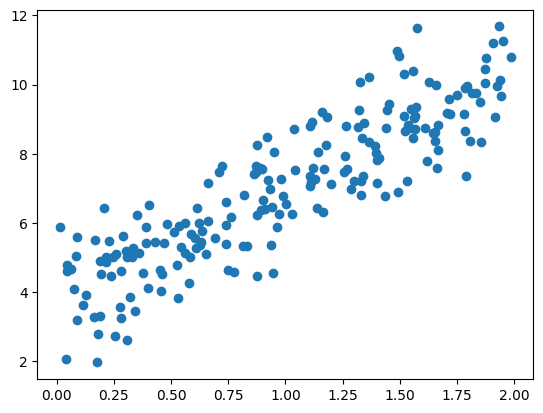

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X,y,alpha=1.)

In [6]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.69084138],
       [3.32960458]])

In [7]:
#y = X * theta 

X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

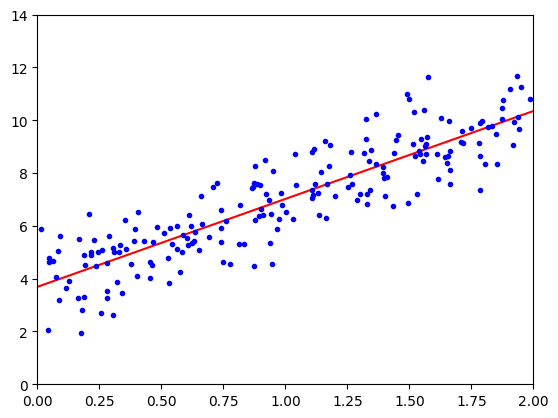

In [8]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X,y, "b.", alpha=1)
plt.axis([0,2,0,14])

plt.show()

In [9]:
# eta = 0.1
# n_epochs = 1000
# m = len(X_b)

# rng = np.random.default_rng(seed=42)
# theta = rng.standard_normal((2,1))

# for epoch in range(n_epochs):
#     gradients = 2/m * X_b.T @ (X_b@theta - y)
#     theta = theta - eta * gradients

# theta

[[3.69084138]
 [3.32960458]]


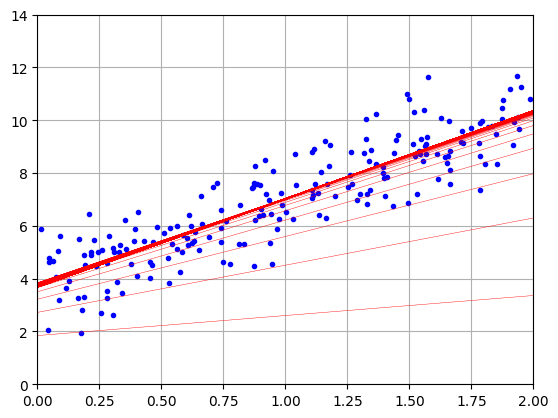

In [10]:
plt.plot(X, y, "b.") #og data
plt.axis([0, 2, 0, 14])

def smooth(epoch, total_epochs, start=0.3, end=1.0):
    progress = (epoch - 1) / (total_epochs - 1)
    return start + (end - start) * progress

def plot_theta(theta, epoch, n_epochs):
    X_new = np.array([[0], [2]])
    X_new_b = add_dummy_feature(X_new)
    y_predict = X_new_b @ theta
    plt.plot(X_new, y_predict, "r-", linewidth= smooth(epoch, n_epochs))

eta = 0.1
n_epochs = 1000
m = len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
    gradients = 2/m * X_b.T @ (X_b@theta - y)
    theta = theta - eta * gradients
    plot_theta(theta, epoch, n_epochs)

print(theta)
plt.grid(True)

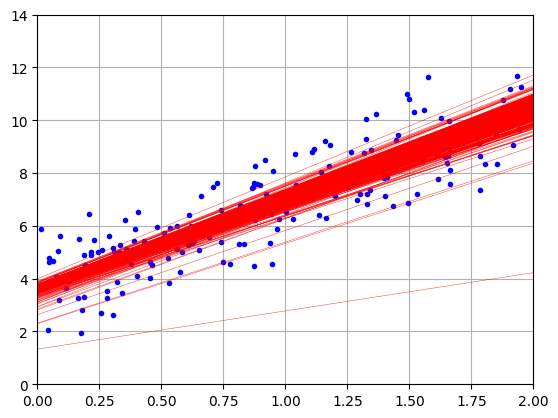

In [11]:
#Stochastic gradient descent

n_epochs = 20
t0, t1 = 5,50

def learning_schedule(t):
    return t0 / (t1 + t)

theta = rng.standard_normal((2,1))

plt.plot(X, y, "b.") #og data
plt.axis([0, 2, 0, 14])

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index: random_index+1]
        yi = y[random_index: random_index+1]

        gradients = 2 * xi.T * (xi@theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

        plot_theta(theta, epoch, n_epochs)

plt.grid(True)


In [12]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())

sgd_reg.intercept_, sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

<h1>Polynomial Regression</h1>

(200, 1)

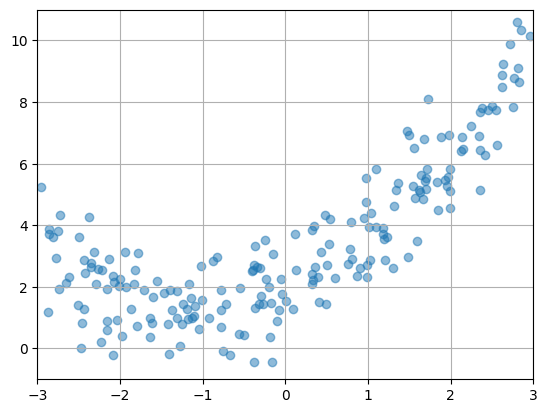

In [13]:
rng = np.random.default_rng(seed=42)

m = 200 # number of instances
X = 6 * rng.random((m, 1)) - 3 # column vector
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1)) # column vector

plt.scatter(X,y,alpha=0.5)
plt.grid(True)
plt.axis([-3,3, -1,11])

y.shape

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

# y_pred = lin_reg.predict(X_poly)

(array([2.00540719]), array([[1.11022126, 0.50526985]]))

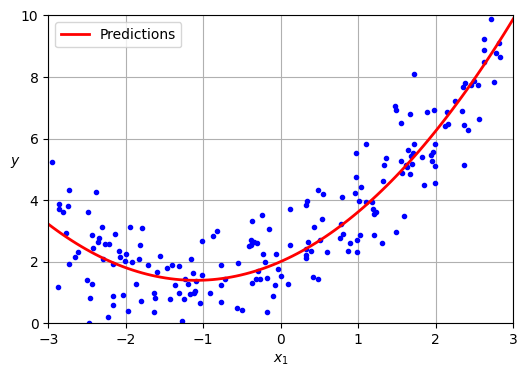

In [15]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()

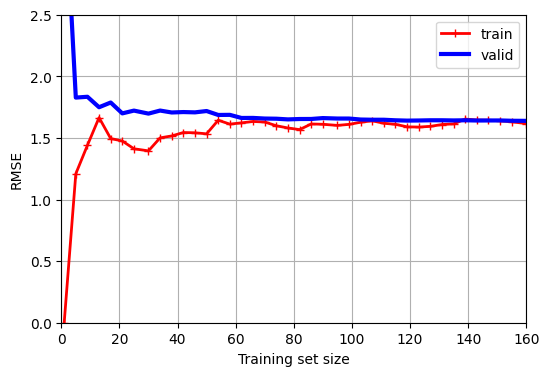

In [16]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 160, 0, 2.5])

plt.show()

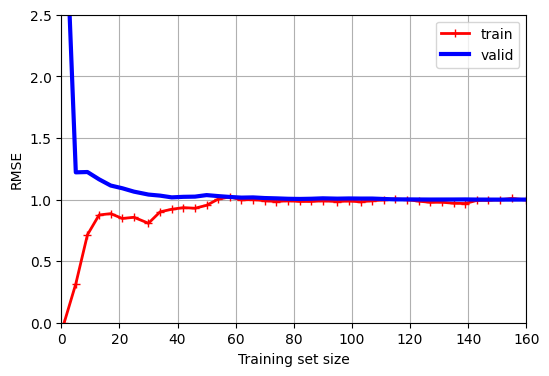

In [17]:
from sklearn.pipeline import make_pipeline

p_reg = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False), LinearRegression()
)

train_sizes, train_scores, valid_scores = learning_curve(
    p_reg,
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 160, 0, 2.5])

plt.show()

In [18]:
#working with iris

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == "virginica"

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


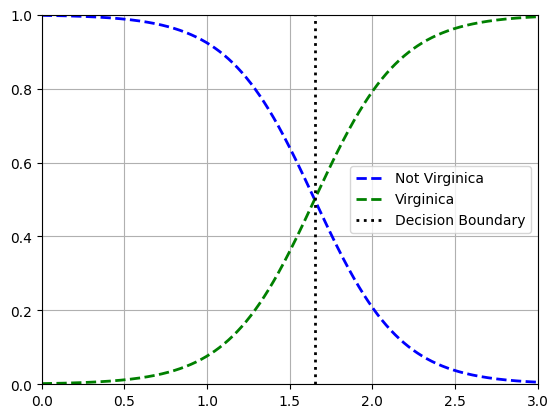

In [20]:
X_new = np.linspace(0,3,1000).reshape(-1,1)

y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:,1] >= 0.5][0,0]

plt.plot(X_new, y_proba[:,0], "b--", linewidth = 2, label = "Not Virginica")
plt.plot(X_new, y_proba[:,1], "g--", linewidth = 2, label = "Virginica")
plt.plot([decision_boundary,decision_boundary], [0,1], "k:", linewidth = 2, label = "Decision Boundary")
plt.legend()
plt.axis([0,3,0,1])
plt.grid(True)


In [21]:
# softmax regression

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# C is regulation hyperparam
softmax_reg = LogisticRegression(C=30, random_state=42) 
softmax_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,30
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
softmax_reg.predict_proba([[5,2], [6,2]]).round(2)

array([[0.  , 0.04, 0.96],
       [0.  , 0.  , 1.  ]])

In [243]:
# Implement batch gradient descent with early stopping for softmax regression
# without using Scikit-Learn, only NumPy. Use it on a classification task such as
# the iris dataset.

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

X_with_bias = np.c_[np.ones(len(X)), X]
X_with_bias

test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(test_ratio * total_size)
validation_size = int(validation_ratio * total_size)
train_size = total_size - test_size - validation_size

rng = np.random.default_rng(seed=42)
rnd_indices = rng.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

y_valid

array([2, 0, 1, 1, 2, 0, 2, 2, 2, 0, 2, 1, 1, 0, 2, 0, 1, 1, 2, 0, 2, 2,
       0, 0, 1, 2, 0, 1, 0, 2])

In [244]:
#one-hot encoding y values

def to_onehot(y):
    return np.diag(np.ones(y.max()+1))[y]

y_train_oh = to_onehot(y_train)
y_test_oh = to_onehot(y_test)
y_valid_oh = to_onehot(y_valid)

In [245]:
#scaling

def scale(X):
    mean = np.mean(X[:, 1:], axis=0)
    std = np.std(X[:, 1:], axis=0)
    return (X[:, 1:] - mean)/std

X_train[:, 1:] = scale(X_train)
X_valid[:, 1:] = scale(X_valid)
X_test[:, 1:] = scale(X_test)

In [246]:
def softmax(logit):
    exps = np.exp(logit)
    exp_sums = exps.sum(axis=1, keepdims = True)
    return exps / exp_sums

In [247]:
n_inputs = X_train.shape[1]
n_outputs = len(np.unique(y_train))

In [293]:
#implementing cost functions 

eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5

Theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ Theta
    probabilites = softmax(logits)

    if (epoch % 1000 == 0):
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(y_valid_oh * np.log(Y_proba_valid + epsilon))
        print(epoch, xentropy_losses.sum(axis=1).mean())

    error = probabilites - y_train_oh
    gradients = (1 / m) * X_train.T @ error 
    Theta = Theta - eta * gradients


0 1.6329988981468802
1000 0.11399581111070468
2000 0.10828959583406979
3000 0.10664443995318146
4000 0.10600070460653818
5000 0.10571893091120428


In [294]:
def checkValid(thet):
    logits = X_valid @ thet
    Y_proba = softmax(logits)
    y_predict = Y_proba.argmax(axis=1)

    accuracy_score = (y_predict == y_valid).mean()
    print("Accuracy: ",accuracy_score.round(4))

checkValid(Theta)

Accuracy:  0.9667


In [295]:
#adding l2 regularisation

#implementing cost functions 
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5
alpha = 0.01

rng = np.random.default_rng(seed=42)
Theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ Theta
    probabilites = softmax(logits)

    if (epoch % 1000 == 0):
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(y_valid_oh * np.log(Y_proba_valid + epsilon))
        l2_losses = 1/2 * (Theta[1:]**2).sum()
        total_loss = xentropy_losses.sum(axis=1).mean() + alpha * l2_losses
        print(epoch, total_loss.round(4))

    error = probabilites - y_train_oh
    gradients = (1 / m) * X_train.T @ error 
    gradients += np.r_[np.zeros([1, n_outputs]), alpha * Theta[1:]]
    Theta = Theta - eta * gradients

0 2.8789
1000 0.3088
2000 0.3088
3000 0.3088
4000 0.3088
5000 0.3088


In [296]:
checkValid(Theta)

Accuracy:  0.9333


In [297]:
eta = 0.5  # learning rate
n_epochs = 50_001
m = len(X_train)  # number of instances
epsilon = 1e-5
C = 100  # regularization hyperparameter
best_loss = np.inf

rng = np.random.default_rng(seed=42)
Theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)
    xentropy_losses = -(y_valid_oh * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss
    if epoch % 1000 == 0:
        print(epoch, total_loss.round(4))
    if total_loss < best_loss:
        best_loss = total_loss
    else:
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_loss.round(4), "early stopping!")
        break
    error = Y_proba - y_train_oh
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
    Theta = Theta - eta * gradients

0 2.8789
1000 0.3088
2000 0.3088
3000 0.3088
4000 0.3088
4941 0.3088
4942 0.3088 early stopping!


In [298]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)